# Sentinel 12A — Max Return (net) with Drawdown Target (~30%)

Versión enfocada en **Opción A**:
- Maximizar retorno **neto** con objetivo de **MaxDD ~ 30%** (en VALIDATION, sin tocar el TEST).
- Baselines ahora son comparables: mismas reglas de ejecución (shift), **mismos costos**, y reporte en **FULL** y **FINAL TEST**.
- `Regime` 3-estados se reemplaza por **Crisis Gate mínimo** (binario con histéresis), porque tu ablation mostró que `Regime` estaba quitando retorno sin mejorar DD.
- Se mantiene eliminación de **look-ahead**: todo escalado se aplica en **t+1**.

Al final se generan CSV en `outputs/`.



SENTINEL 12A — SWEEP (Top 10) — score en VALIDATION (Objective A: return net + DD~30)
 top_k  weight_cap  vol_target_ann  turb_scale_min  score_val  VAL_CAGR%  VAL_Sharpe  VAL_MaxDD%  VAL_TurnoverAnn  FINALTEST_CAGR%  FINALTEST_Sharpe  FINALTEST_MaxDD%  FINALTEST_TurnoverAnn  FINALTEST_ExcessCAGR_vsQQQ%  FINALTEST_ExcessCAGR_vsEQW%  FINALTEST_ExcessCAGR_vsMOM%
     3        0.65            0.34            0.45     0.4157    38.2359      1.5389    -28.1388          14.7198          33.8708            1.1919          -35.2111                13.2188                      14.5748                       2.2863                      -7.6450
     3        0.55            0.34            0.45     0.4029    37.5866      1.5228    -28.1388          14.6565          33.9326            1.1951          -35.2952                13.0969                      14.6365                       2.3481                      -7.5832
     3        0.65            0.30            0.45     0.3721    35.7788      1.50

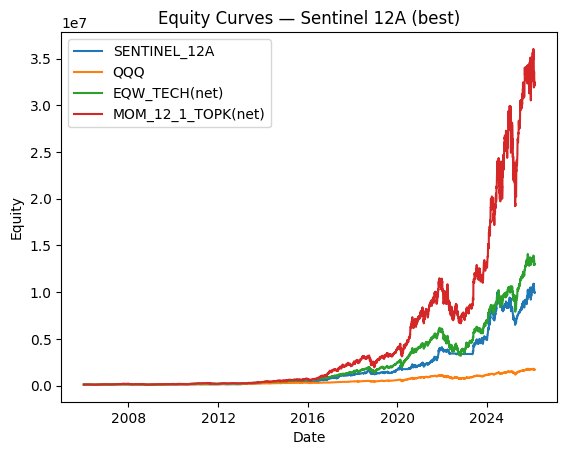

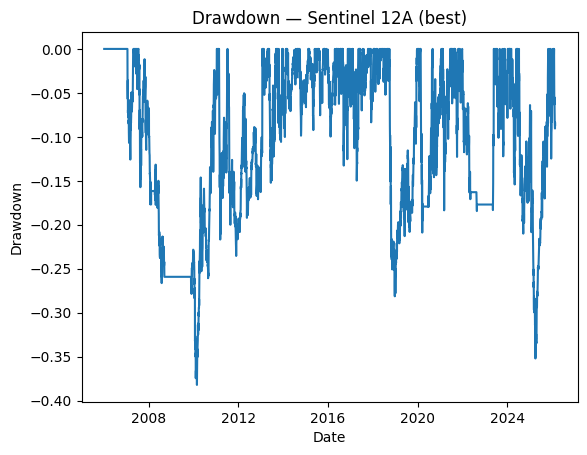

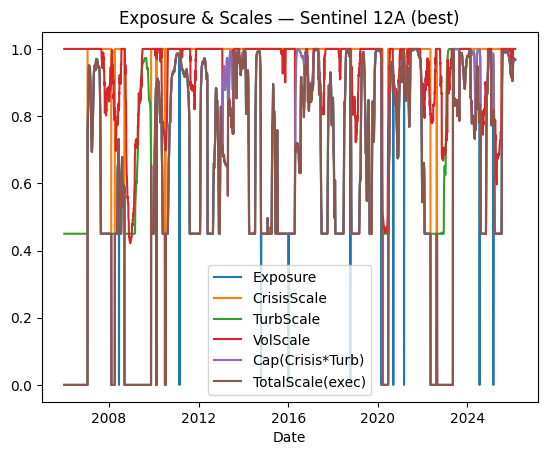

In [1]:
\
import warnings
warnings.filterwarnings("ignore")

import os
import json
import hashlib
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# =========================
# CONFIG — SENTINEL 12A
# =========================

@dataclass
class CostsConfig:
    commission: float = 0.001
    slippage: float = 0.0002
    apply_slippage: bool = True

@dataclass
class Tech12AConfig:
    capital_initial: float = 100000.0
    start: str = "2006-01-01"
    end: str = "2026-02-20"
    trading_days: int = 252
    rf_annual: float = 0.0

    # Splits (NO optimizar sobre el test final)
    train_start: str = "2006-01-01"
    train_end: str   = "2014-12-31"
    val_start: str   = "2015-01-01"
    val_end: str     = "2019-12-31"
    test_start: str  = "2020-01-01"
    test_end: str    = "2026-02-20"

    # Universo Tech
    universe: Tuple[str, ...] = ('AAPL','MSFT','NVDA','GOOGL','AMZN','META','AVGO','ASML','TSM','ADBE','NFLX','AMD')

    # Benchmarks
    bench_qqq: str = "QQQ"
    bench_spy: str = "SPY"
    bench_ndx: str = "^NDX"

    # Cache
    cache_dir: str = "data_cache"

    # Rebalance y selección
    rebalance_freq: str = "W-FRI"
    top_k: int = 3

    # -------- Señal (self-tuning ER) --------
    er_window: int = 30
    spans_short: Tuple[int, ...] = (42, 84, 126)
    spans_long:  Tuple[int, ...] = (63, 126, 252)
    mom_windows: Tuple[int, ...] = (63, 126, 252)
    rel_windows: Tuple[int, ...] = (63, 126)
    w_trend: float = 0.50
    w_mom: float = 0.30
    w_rel: float = 0.20
    burn_in: int = 260

    # -------- HRP --------
    hrp_use: bool = True
    hrp_window: int = 252
    weight_cap: float = 0.65
    cov_shrink: float = 0.10

    # -------- Stop (Chandelier) --------
    atr_window: int = 21
    k_base: float = 2.6
    k_er_gain: float = 1.2
    stop_on: bool = True
    allow_reentry: bool = True
    stop_keep_cash: bool = False  # False = renormaliza (max return); True = deja cash (más realista)

    # -------- Crisis Gate (mínimo) --------
    crisis_gate_use: bool = True
    crisis_dd_threshold: float = 0.20
    crisis_vol_threshold: float = 0.45
    crisis_min_days_on: int = 4
    crisis_min_days_off: int = 6
    crisis_scale: float = 0.0

    # -------- Turbulence & liquidity filter --------
    turb_use: bool = True
    turb_window: int = 63
    illiq_window: int = 21
    turb_sigmoid_a: float = 1.2
    turb_sigmoid_b: float = 0.5
    turb_scale_min: float = 0.30
    turb_eval_on_rebalance_only: bool = True

    # -------- Vol targeting --------
    vol_target_on: bool = True
    vol_target_ann: float = 0.30
    port_vol_window: int = 63
    max_exposure: float = 1.0
    min_exposure: float = 0.0

    # -------- Objective A controls --------
    target_maxdd: float = 0.30
    dd_penalty_strength: float = 2.0
    turnover_soft_cap: float = 15.0

    # -------- Engineering --------
    random_seed: int = 42

STRESS_EPISODES = {
    "GFC_2008": ("2008-01-01", "2009-06-30"),
    "EURO_2011": ("2011-07-01", "2011-12-31"),
    "Q4_2018": ("2018-10-01", "2018-12-31"),
    "COVID_2020": ("2020-02-15", "2020-06-30"),
    "RATES_2022": ("2022-01-01", "2022-12-31"),
}

# =========================
# HELPERS
# =========================

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def _hash_key(obj: dict) -> str:
    s = json.dumps(obj, sort_keys=True).encode("utf-8")
    return hashlib.md5(s).hexdigest()

def to_1d_series(x, name="x") -> pd.Series:
    if x is None:
        return pd.Series(dtype=float, name=name)
    if isinstance(x, pd.Series):
        return x.rename(name)
    if isinstance(x, pd.DataFrame):
        if x.shape[1] == 0:
            return pd.Series(dtype=float, name=name)
        return x.iloc[:, 0].rename(name)
    arr = np.asarray(x)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr.reshape(-1)
    return pd.Series(arr, name=name)

def safe_zscore(s: pd.Series, window: int = 252) -> pd.Series:
    m = s.rolling(window).mean()
    sd = s.rolling(window).std().replace(0, np.nan)
    z = (s - m) / sd
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# =========================
# DATA
# =========================

def download_ohlcv_cached(tickers: List[str], start: str, end: str, cache_dir: str) -> Dict[str, pd.DataFrame]:
    _ensure_dir(cache_dir)
    key = _hash_key({"tickers": tickers, "start": start, "end": end, "auto_adjust": True, "ohlcv": True, "v": 3})
    path = os.path.join(cache_dir, f"ohlcv_{key}.pkl")

    if os.path.exists(path):
        return pd.read_pickle(path)

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, group_by="ticker", progress=False)

    idx = pd.DatetimeIndex(raw.index)
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_localize(None)
    idx = idx[~idx.duplicated()]

    close = pd.DataFrame(index=idx)
    high  = pd.DataFrame(index=idx)
    low   = pd.DataFrame(index=idx)
    vol   = pd.DataFrame(index=idx)

    for t in tickers:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                c = raw[(t, "Close")] if (t, "Close") in raw.columns else None
                h = raw[(t, "High")]  if (t, "High")  in raw.columns else None
                l = raw[(t, "Low")]   if (t, "Low")   in raw.columns else None
                v = raw[(t, "Volume")]if (t, "Volume")in raw.columns else None
            else:
                c = raw["Close"] if "Close" in raw.columns else None
                h = raw["High"]  if "High"  in raw.columns else None
                l = raw["Low"]   if "Low"   in raw.columns else None
                v = raw["Volume"]if "Volume"in raw.columns else None

            if c is None:
                continue

            close[t] = pd.Series(c, index=raw.index).reindex(idx).ffill(limit=5)
            high[t]  = pd.Series(h, index=raw.index).reindex(idx).ffill(limit=5) if h is not None else close[t]
            low[t]   = pd.Series(l, index=raw.index).reindex(idx).ffill(limit=5) if l is not None else close[t]
            vol[t]   = pd.Series(v, index=raw.index).reindex(idx).ffill(limit=5) if v is not None else np.nan
        except Exception:
            continue

    out = {
        "close": close.dropna(how="all"),
        "high":  high.dropna(how="all"),
        "low":   low.dropna(how="all"),
        "volume":vol.dropna(how="all"),
    }
    pd.to_pickle(out, path)
    return out

# =========================
# HRP
# =========================

def _shrink_cov(cov: pd.DataFrame, lam: float) -> pd.DataFrame:
    if lam <= 0:
        return cov
    lam = float(np.clip(lam, 0.0, 1.0))
    diag = np.diag(np.diag(cov.values))
    shr = (1.0 - lam) * cov.values + lam * diag
    return pd.DataFrame(shr, index=cov.index, columns=cov.columns)

def hrp_weights(returns: pd.DataFrame, cov_shrink: float = 0.0) -> pd.Series:
    try:
        from scipy.cluster.hierarchy import linkage
        from scipy.spatial.distance import squareform
    except Exception:
        cov = _shrink_cov(returns.cov(), cov_shrink)
        iv = 1.0 / np.diag(cov)
        w = iv / iv.sum()
        return pd.Series(w, index=returns.columns)

    cov = _shrink_cov(returns.cov(), cov_shrink)
    corr = returns.corr()
    dist = np.sqrt(0.5 * (1 - corr)).clip(0, 1)
    dist_cond = squareform(dist.values, checks=False)
    link = linkage(dist_cond, method="single")

    def _get_quasi_diag(linkage_matrix):
        linkage_matrix = linkage_matrix.astype(int)
        sort_ix = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
        num_items = linkage_matrix[-1, 3]
        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i = df0.index
            j = df0.values - num_items
            sort_ix[i] = linkage_matrix[j, 0]
            df1 = pd.Series(linkage_matrix[j, 1], index=i + 1)
            sort_ix = pd.concat([sort_ix, df1]).sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()

    sort_ix = _get_quasi_diag(link)
    ordered = corr.index[sort_ix]
    cov_ = cov.loc[ordered, ordered]
    w = pd.Series(1.0, index=ordered)

    def _cluster_var(cov_mat, items):
        sub = cov_mat.loc[items, items]
        iv = 1.0 / np.diag(sub)
        iv = iv / iv.sum()
        return float(iv.T @ sub.values @ iv)

    clusters = [ordered.tolist()]
    while True:
        clusters = [c for c in clusters if len(c) > 1]
        if not clusters:
            break
        new_clusters = []
        for c in clusters:
            split = len(c) // 2
            c1, c2 = c[:split], c[split:]
            var1, var2 = _cluster_var(cov_, c1), _cluster_var(cov_, c2)
            alpha = 1.0 - var1 / (var1 + var2) if (var1 + var2) != 0 else 0.5
            w[c1] *= alpha
            w[c2] *= (1 - alpha)
            new_clusters += [c1, c2]
        clusters = new_clusters

    return (w / w.sum()).astype(float)

# =========================
# SIGNAL
# =========================

def efficiency_ratio(price: pd.Series, n: int) -> pd.Series:
    change = (price - price.shift(n)).abs()
    vol = price.diff().abs().rolling(n).sum()
    er = (change / vol).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return er.clip(0, 1)

def trend_vote(price: pd.Series, spans: Tuple[int, ...]) -> pd.Series:
    votes = []
    for s in spans:
        ema = price.ewm(span=s, adjust=False).mean().shift(1)
        votes.append(((price > ema) & price.notna() & ema.notna()).astype(float))
    return sum(votes) / len(votes)

def compute_scores(close: pd.DataFrame, qqq_close: pd.Series, cfg: Tech12AConfig) -> pd.DataFrame:
    idx = close.index
    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    scores = pd.DataFrame(index=idx, columns=close.columns, dtype=float)

    for t in close.columns:
        p = close[t].reindex(idx).ffill()
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)

        tr_short = trend_vote(p, cfg.spans_short)
        tr_long  = trend_vote(p, cfg.spans_long)
        trend = er_star * tr_short + (1 - er_star) * tr_long

        moms = [(p / p.shift(w) - 1.0).shift(1) for w in cfg.mom_windows]
        mom_raw = sum(moms) / len(moms)
        mom = ((mom_raw.clip(-1, 1) + 1.0) / 2.0)

        rels = []
        for w in cfg.rel_windows:
            a = (p / p.shift(w) - 1.0).shift(1)
            b = (qqq / qqq.shift(w) - 1.0).shift(1)
            rels.append(a - b)
        rel_raw = sum(rels) / len(rels)
        rel = ((rel_raw.clip(-1, 1) + 1.0) / 2.0)

        s = cfg.w_trend * trend + cfg.w_mom * mom + cfg.w_rel * rel
        s.iloc[:cfg.burn_in] = 0.0
        scores[t] = s.fillna(0.0)

    return scores.fillna(0.0)

def select_topk(scores: pd.DataFrame, k: int, freq: str) -> pd.DataFrame:
    idx = scores.index
    reb_dates = scores.resample(freq).last().index
    mask = pd.DataFrame(0.0, index=idx, columns=scores.columns)
    last = np.zeros(scores.shape[1])
    cols = list(scores.columns)
    for dt in idx:
        if dt in reb_dates:
            row = scores.loc[dt].values
            order = np.argsort(-row)
            top = set(order[:k])
            last = np.array([1.0 if i in top else 0.0 for i in range(len(cols))], dtype=float)
        mask.loc[dt] = last
    return mask.fillna(0.0)

# =========================
# STOP
# =========================

def atr_true(high: pd.Series, low: pd.Series, close: pd.Series, window: int) -> pd.Series:
    prev = close.shift(1)
    tr = pd.concat([(high - low).abs(), (high - prev).abs(), (low - prev).abs()], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def apply_chandelier_stop(weights: pd.DataFrame,
                          close: pd.DataFrame, high: pd.DataFrame, low: pd.DataFrame,
                          cfg: Tech12AConfig) -> Tuple[pd.DataFrame, int]:
    if not cfg.stop_on:
        return weights, 0

    out = weights.copy()
    idx = out.index
    reb_dates = out.resample(cfg.rebalance_freq).last().index
    stop_hits = 0

    for t in out.columns:
        p = close[t].reindex(idx).ffill()
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)

        atr = atr_true(high[t].reindex(idx).ffill(),
                       low[t].reindex(idx).ffill(), p, cfg.atr_window)
        atr = atr.fillna(method="bfill").fillna(0.0)

        k_t = (cfg.k_base + cfg.k_er_gain * er_star).clip(1.6, 4.5)

        wt = out[t].values
        in_pos = False
        maxp = np.nan
        stopped = False

        for i, dt in enumerate(idx):
            if dt in reb_dates and cfg.allow_reentry:
                stopped = False

            if wt[i] <= 0:
                in_pos = False
                maxp = np.nan
                continue

            if stopped:
                wt[i] = 0.0
                continue

            if not in_pos:
                in_pos = True
                maxp = float(p.iloc[i])
            else:
                maxp = max(maxp, float(p.iloc[i]))

            stop_level = maxp - float(k_t.iloc[i]) * float(atr.iloc[i])
            if float(p.iloc[i]) < stop_level:
                wt[i] = 0.0
                stopped = True
                in_pos = False
                maxp = np.nan
                stop_hits += 1

        out[t] = wt

    if not cfg.stop_keep_cash:
        denom = out.sum(axis=1).replace(0, np.nan)
        out = out.div(denom, axis=0).fillna(0.0)
    else:
        out = out.clip(lower=0.0)
    return out, stop_hits

# =========================
# Crisis Gate + Turbulence
# =========================

def compute_crisis_gate(qqq_close: pd.Series, cfg: Tech12AConfig) -> Tuple[pd.Series, pd.Series]:
    p = to_1d_series(qqq_close, "QQQ").ffill()
    idx = p.index
    r = p.pct_change().fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    vol = vol.fillna(method="bfill").fillna(0.0)
    dd = p / p.cummax() - 1.0

    cond = ((dd <= -cfg.crisis_dd_threshold) | (vol >= cfg.crisis_vol_threshold)).astype(int)
    on = cond.rolling(cfg.crisis_min_days_on).mean().fillna(0.0) >= 0.8
    off = (1 - cond).rolling(cfg.crisis_min_days_off).mean().fillna(0.0) >= 0.8

    state = pd.Series(0.0, index=idx)  # 0 normal, 1 crisis
    in_crisis = False
    for dt in idx:
        if not in_crisis and bool(on.loc[dt]):
            in_crisis = True
        elif in_crisis and bool(off.loc[dt]):
            in_crisis = False
        state.loc[dt] = 1.0 if in_crisis else 0.0

    scale = pd.Series(1.0, index=idx, dtype=float)
    if cfg.crisis_gate_use:
        scale[state == 1.0] = cfg.crisis_scale

    scale.iloc[:cfg.burn_in] = cfg.crisis_scale
    state.iloc[:cfg.burn_in] = 1.0
    return scale, state

def compute_turbulence(close: pd.DataFrame, volume: pd.DataFrame, qqq_close: pd.Series, cfg: Tech12AConfig) -> pd.Series:
    idx = close.index
    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    qqq_r = qqq.pct_change().fillna(0.0)
    vol_q = (qqq_r.rolling(cfg.turb_window).std() * np.sqrt(cfg.trading_days)).fillna(0.0)

    rets = close.pct_change().fillna(0.0)

    avg_corr = pd.Series(0.0, index=idx)
    w = cfg.turb_window
    if cfg.turb_eval_on_rebalance_only:
        reb_dates = close.resample(cfg.rebalance_freq).last().index
        for dt in reb_dates:
            if dt not in idx:
                continue
            loc = idx.get_loc(dt)
            if loc < w:
                continue
            sub = rets.iloc[loc-w+1:loc+1]
            c = sub.corr().values
            n = c.shape[0]
            avg_corr.loc[dt] = (c.sum() - n) / (n*(n-1)) if n > 1 else 0.0
        avg_corr = avg_corr.replace(0, np.nan).ffill().fillna(0.0)
    else:
        for i in range(len(idx)):
            if i < w:
                continue
            sub = rets.iloc[i-w+1:i+1]
            c = sub.corr().values
            n = c.shape[0]
            avg_corr.iloc[i] = (c.sum() - n) / (n*(n-1)) if n > 1 else 0.0

    dv = (close * volume).replace(0, np.nan)
    illiq = (rets.abs() / dv).replace([np.inf, -np.inf], np.nan)
    illiq_avg = illiq.rolling(cfg.illiq_window).mean().mean(axis=1).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    turb = safe_zscore(vol_q, 252) + safe_zscore(avg_corr, 252) + safe_zscore(illiq_avg, 252)
    turb = turb.ewm(span=10, adjust=False).mean()

    a, b = cfg.turb_sigmoid_a, cfg.turb_sigmoid_b
    s = 1.0 / (1.0 + np.exp(a * (turb - b)))
    s = pd.Series(s, index=idx).clip(lower=cfg.turb_scale_min, upper=1.0)
    s.iloc[:cfg.burn_in] = cfg.turb_scale_min
    return s

# =========================
# Vol targeting
# =========================

def vol_target_scale(port_gross: pd.Series, cfg: Tech12AConfig) -> pd.Series:
    if not cfg.vol_target_on:
        return pd.Series(1.0, index=port_gross.index)
    r = to_1d_series(port_gross, "r").fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    scale = (cfg.vol_target_ann / vol).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    return scale.clip(lower=cfg.min_exposure, upper=cfg.max_exposure)

# =========================
# Backtest (no look-ahead)
# =========================

def backtest_sentinel12A(ohlcv: Dict[str, pd.DataFrame], cfg: Tech12AConfig, costs: CostsConfig) -> Dict:
    np.random.seed(cfg.random_seed)

    close = ohlcv["close"][list(cfg.universe)].copy()
    high  = ohlcv["high"][list(cfg.universe)].copy()
    low   = ohlcv["low"][list(cfg.universe)].copy()
    vol   = ohlcv["volume"][list(cfg.universe)].copy()
    idx = close.index

    qqq = ohlcv["close"][cfg.bench_qqq].reindex(idx).ffill()
    spy = ohlcv["close"][cfg.bench_spy].reindex(idx).ffill()
    ndx = ohlcv["close"][cfg.bench_ndx].reindex(idx).ffill() if cfg.bench_ndx in ohlcv["close"].columns else None

    crisis_scale, crisis_state = compute_crisis_gate(qqq, cfg) if cfg.crisis_gate_use else (pd.Series(1.0, index=idx), pd.Series(0.0, index=idx))
    turb_scale = compute_turbulence(close, vol, qqq, cfg) if cfg.turb_use else pd.Series(1.0, index=idx)

    scores = compute_scores(close, qqq, cfg)
    active_mask = select_topk(scores, cfg.top_k, cfg.rebalance_freq)

    rets = close.pct_change().fillna(0.0)
    reb_dates = close.resample(cfg.rebalance_freq).last().index

    w = pd.DataFrame(0.0, index=idx, columns=close.columns)
    last_w = pd.Series(0.0, index=close.columns)

    for dt in idx:
        if dt in reb_dates:
            sel = active_mask.loc[dt]
            names = sel[sel > 0].index.tolist()

            if len(names) == 0:
                last_w = pd.Series(0.0, index=close.columns)
            elif len(names) == 1:
                last_w = pd.Series(0.0, index=close.columns)
                last_w[names[0]] = 1.0
            else:
                lookback = rets.loc[:dt].tail(cfg.hrp_window)
                sub = lookback[names].dropna()

                if len(sub) < 60 or (not cfg.hrp_use):
                    cov = _shrink_cov(sub.cov(), cfg.cov_shrink)
                    iv = 1.0 / np.diag(cov)
                    ww = pd.Series(iv / iv.sum(), index=names)
                else:
                    ww = hrp_weights(sub, cov_shrink=cfg.cov_shrink)

                ww = ww.clip(upper=cfg.weight_cap)
                ww = ww / ww.sum()

                last_w = pd.Series(0.0, index=close.columns)
                last_w[names] = ww.values

        w.loc[dt] = last_w.values

    w_stop, stop_hits = apply_chandelier_stop(w, close, high, low, cfg)

    # Execution-aligned
    w_exec_1x = w_stop.shift(1).fillna(0.0)
    port_gross_1x = (w_exec_1x * rets).sum(axis=1)

    vol_scale = vol_target_scale(port_gross_1x, cfg)
    cap = (crisis_scale * turb_scale).clip(lower=0.0, upper=cfg.max_exposure)

    total_scale_tgt = pd.Series(np.minimum(vol_scale.values, cap.values), index=idx).clip(0.0, cfg.max_exposure)
    total_scale_exec = total_scale_tgt.shift(1).fillna(0.0)

    w_exec = w_exec_1x.mul(total_scale_exec, axis=0)

    dw = w_exec.diff().abs().fillna(0.0)
    to = 0.5 * dw.sum(axis=1)
    tc = to * (costs.commission + (costs.slippage if costs.apply_slippage else 0.0))

    port_net = ((w_exec * rets).sum(axis=1) - tc).replace([np.inf, -np.inf], 0.0).fillna(0.0)

    equity = cfg.capital_initial * (1.0 + port_net).cumprod()
    exposure = w_exec.abs().sum(axis=1).clip(0, cfg.max_exposure)

    qqq_r = qqq.pct_change().fillna(0.0)
    spy_r = spy.pct_change().fillna(0.0)
    qqq_eq = cfg.capital_initial * (1.0 + qqq_r).cumprod()
    spy_eq = cfg.capital_initial * (1.0 + spy_r).cumprod()

    if ndx is not None:
        ndx_r = ndx.pct_change().fillna(0.0)
        ndx_eq = cfg.capital_initial * (1.0 + ndx_r).cumprod()
    else:
        ndx_r, ndx_eq = None, None

    return {
        "returns_net": port_net,
        "equity": equity,
        "exposure": exposure,
        "turnover": to,
        "weights_scaled": w_exec,
        "total_scale": total_scale_exec,
        "total_scale_target": total_scale_tgt,
        "cap": cap,
        "turb_scale": turb_scale,
        "crisis_scale": crisis_scale,
        "vol_scale": vol_scale,
        "stop_hits": stop_hits,
        "bench": {"QQQ_r": qqq_r, "QQQ_eq": qqq_eq, "SPY_r": spy_r, "SPY_eq": spy_eq, "NDX_r": ndx_r, "NDX_eq": ndx_eq},
    }

# =========================
# Metrics
# =========================

def total_return(r: pd.Series) -> float:
    r = to_1d_series(r, "r").dropna()
    return float((1.0 + r).prod() - 1.0) if len(r) else 0.0

def cagr(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    if len(r) == 0:
        return 0.0
    tr = (1.0 + r).prod() - 1.0
    return float((1.0 + tr) ** (td / len(r)) - 1.0)

def ann_vol(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    sd = r.std(ddof=1)
    return float(sd * np.sqrt(td)) if sd == sd else np.nan

def sharpe(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    sd = ex.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def sortino(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    dn = ex.copy()
    dn[dn > 0] = 0
    sd = dn.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def max_dd(eq: pd.Series) -> float:
    eq = to_1d_series(eq, "eq").dropna()
    if len(eq) == 0:
        return 0.0
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())

def calmar(r: pd.Series, eq: pd.Series, td=252) -> float:
    a = cagr(r, td)
    d = max_dd(eq)
    return float(a / abs(d)) if d != 0 else np.inf

def cvar(r: pd.Series, alpha=0.05) -> float:
    x = to_1d_series(r, "r").dropna().values
    if len(x) == 0:
        return np.nan
    q = np.quantile(x, alpha)
    tail = x[x <= q]
    return float(tail.mean()) if len(tail) else float(q)

def summarize(r: pd.Series, eq: pd.Series, exposure: Optional[pd.Series], turnover: Optional[pd.Series], cfg: Tech12AConfig) -> Dict:
    r = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna()
    eq = to_1d_series(eq, "eq").dropna()
    exp = to_1d_series(exposure, "exp").reindex(r.index).fillna(0.0) if exposure is not None else pd.Series(np.nan, index=r.index)
    to = to_1d_series(turnover, "to").reindex(r.index).fillna(0.0) if turnover is not None else pd.Series(0.0, index=r.index)
    return {
        "FinalEquity": float(eq.iloc[-1]) if len(eq) else np.nan,
        "TotalReturn": total_return(r),
        "CAGR": cagr(r, cfg.trading_days),
        "AnnVol": ann_vol(r, cfg.trading_days),
        "Sharpe": sharpe(r, cfg.rf_annual, cfg.trading_days),
        "Sortino": sortino(r, cfg.rf_annual, cfg.trading_days),
        "MaxDD": max_dd(eq),
        "Calmar": calmar(r, eq, cfg.trading_days),
        "CVaR_5": cvar(r, 0.05),
        "AvgExposure": float(exp.mean()) if exposure is not None else np.nan,
        "TimeInMkt": float((exp > 0).mean()) if exposure is not None else np.nan,
        "TurnoverAnn": float(to.sum() * (cfg.trading_days / len(r))) if len(r) else 0.0,
        "Days": int(len(r)),
    }

def slice_period(r: pd.Series, exp: pd.Series, to: pd.Series, cfg: Tech12AConfig, start: str, end: str) -> Dict:
    rr = r.loc[start:end]
    ee = cfg.capital_initial * (1.0 + rr).cumprod()
    return {"r": rr, "eq": ee, "exp": exp.loc[rr.index], "to": to.loc[rr.index]}

# =========================
# Validations
# =========================

def validate_no_lookahead(res: Dict):
    ts_exec = to_1d_series(res.get("total_scale"), "ts_exec").fillna(0.0)
    ts_tgt = to_1d_series(res.get("total_scale_target"), "ts_tgt").fillna(0.0)
    expected = ts_tgt.shift(1).fillna(0.0)
    max_diff = float((ts_exec - expected).abs().max())
    assert max_diff < 1e-12, f"total_scale_exec no es shift(1) del target (max diff={max_diff})"

    w_exec = res["weights_scaled"]
    dw = w_exec.diff().abs().fillna(0.0)
    to = 0.5 * dw.sum(axis=1)
    to_stored = to_1d_series(res["turnover"], "to_stored").fillna(0.0)
    assert float((to - to_stored).abs().max()) < 1e-10, "Turnover almacenado no coincide con turnover reconstruido"

def validate_calendar(ohlcv: Dict[str, pd.DataFrame]):
    idx = ohlcv["close"].index
    assert idx.is_monotonic_increasing, "Índice no monótono"
    assert idx[0] < idx[-1], "Rango inválido"

# =========================
# Baselines (net-of-costs, comparable)
# =========================

def _apply_costs_from_weights(w_exec: pd.DataFrame, costs: CostsConfig) -> Tuple[pd.Series, pd.Series]:
    dw = w_exec.diff().abs().fillna(0.0)
    to = 0.5 * dw.sum(axis=1)
    tc = to * (costs.commission + (costs.slippage if costs.apply_slippage else 0.0))
    return to, tc

def baseline_equal_weight_universe_bt(ohlcv: Dict[str, pd.DataFrame], cfg: Tech12AConfig, costs: CostsConfig) -> Dict:
    close = ohlcv["close"][list(cfg.universe)].copy()
    idx = close.index
    n = len(cfg.universe)
    w = pd.DataFrame(1.0/n, index=idx, columns=cfg.universe)
    rets = close.pct_change().fillna(0.0)

    w_exec = w.shift(1).fillna(0.0)
    port_gross = (w_exec * rets).sum(axis=1)
    to, tc = _apply_costs_from_weights(w_exec, costs)
    r_net = (port_gross - tc).fillna(0.0)

    eq = cfg.capital_initial * (1.0 + r_net).cumprod()
    exp = w_exec.abs().sum(axis=1)
    return {"r": r_net, "eq": eq, "exp": exp, "to": to}

def baseline_momentum_12_1_topk_bt(ohlcv: Dict[str, pd.DataFrame], cfg: Tech12AConfig, costs: CostsConfig) -> Dict:
    close = ohlcv["close"][list(cfg.universe)].copy()
    mom = (close.shift(21) / close.shift(252+21) - 1.0).shift(1).fillna(0.0)
    sel = select_topk(mom, cfg.top_k, cfg.rebalance_freq)

    denom = sel.sum(axis=1).replace(0, np.nan)
    w = sel.div(denom, axis=0).fillna(0.0)

    rets = close.pct_change().fillna(0.0)
    w_exec = w.shift(1).fillna(0.0)
    port_gross = (w_exec * rets).sum(axis=1)
    to, tc = _apply_costs_from_weights(w_exec, costs)
    r_net = (port_gross - tc).fillna(0.0)

    eq = cfg.capital_initial * (1.0 + r_net).cumprod()
    exp = w_exec.abs().sum(axis=1)
    return {"r": r_net, "eq": eq, "exp": exp, "to": to}

# =========================
# Stress + Bootstrap
# =========================

def moving_block_bootstrap(r: pd.Series, block=20, n_samples=800, seed=42) -> Dict:
    rng = np.random.default_rng(seed)
    x = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna().values
    T = len(x)
    if T < block * 5:
        return {"dd_p50": np.nan, "dd_p95": np.nan, "ruin_prob_50dd": np.nan}
    dds = []
    for _ in range(n_samples):
        starts = rng.integers(0, T - block, size=int(np.ceil(T / block)))
        sample = np.concatenate([x[s:s + block] for s in starts])[:T]
        eq = (1.0 + sample).cumprod()
        peak = np.maximum.accumulate(eq)
        dds.append(np.min(eq / peak - 1.0))
    dds = np.array(dds)
    return {
        "dd_p50": float(np.quantile(dds, 0.50)),
        "dd_p95": float(np.quantile(dds, 0.05)),
        "ruin_prob_50dd": float(np.mean(dds < -0.5)) * 100.0
    }

def stress_report(r: pd.Series, exp: pd.Series, episodes: Dict[str, Tuple[str, str]], cfg: Tech12AConfig) -> pd.DataFrame:
    out = []
    for name, (a, b) in episodes.items():
        sub = r.loc[a:b]
        if len(sub) < 40:
            continue
        total = (1.0 + sub).prod() - 1.0
        worst_day = sub.min()
        best_day = sub.max()
        ee = cfg.capital_initial * (1.0 + sub).cumprod()
        ss = summarize(sub, ee, exp.loc[sub.index], None, cfg)
        out.append({
            "Episode": name,
            "Days": int(len(sub)),
            "Total%": round(total*100, 2),
            "WorstDay%": round(worst_day*100, 2),
            "BestDay%": round(best_day*100, 2),
            "CAGR%": round(ss["CAGR"]*100, 2),
            "Sharpe": round(ss["Sharpe"], 3),
            "MaxDD%": round(ss["MaxDD"]*100, 2),
            "Calmar": round(ss["Calmar"], 3),
            "AvgExposure%": round(ss["AvgExposure"]*100, 1),
            "TimeInMkt%": round(ss["TimeInMkt"]*100, 1),
        })
    return pd.DataFrame(out)

# =========================
# Objective A: Score on VALIDATION
# =========================

def score_objective_A(s_val: Dict, s_qqq_val: Dict, cfg: Tech12AConfig) -> float:
    excess_cagr = s_val["CAGR"] - s_qqq_val["CAGR"]
    excess_sharpe = s_val["Sharpe"] - s_qqq_val["Sharpe"]
    dd_excess = max(0.0, abs(s_val["MaxDD"]) - cfg.target_maxdd)
    dd_penalty = cfg.dd_penalty_strength * dd_excess
    turnover_penalty = 0.01 * max(0.0, s_val["TurnoverAnn"] - cfg.turnover_soft_cap)
    return float(
        1.25 * excess_cagr
        + 0.15 * excess_sharpe
        + 0.10 * (s_val["Calmar"] - s_qqq_val["Calmar"])
        - dd_penalty
        - turnover_penalty
    )

# =========================
# PLOTS
# =========================

def plot_equity(curves: Dict[str, pd.Series], title: str):
    plt.figure()
    for k, s in curves.items():
        s = to_1d_series(s, k).dropna()
        if len(s):
            plt.plot(s.index, s.values, label=k)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Equity"); plt.legend(); plt.show()

def plot_drawdown(eq: pd.Series, title: str):
    eq = to_1d_series(eq, "eq").dropna()
    dd = eq / eq.cummax() - 1.0
    plt.figure()
    plt.plot(dd.index, dd.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Drawdown"); plt.show()

def plot_scales(res: Dict, title: str):
    exp = to_1d_series(res["exposure"], "exp").fillna(0)
    turb = to_1d_series(res["turb_scale"], "turb").fillna(0)
    vol = to_1d_series(res["vol_scale"], "vol").fillna(0)
    cap = to_1d_series(res["cap"], "cap").fillna(0)
    tot = to_1d_series(res["total_scale"], "tot").fillna(0)
    crisis = to_1d_series(res["crisis_scale"], "crisis").fillna(0)
    plt.figure()
    plt.plot(exp.index, exp.values, label="Exposure")
    plt.plot(crisis.index, crisis.values, label="CrisisScale")
    plt.plot(turb.index, turb.values, label="TurbScale")
    plt.plot(vol.index, vol.values, label="VolScale")
    plt.plot(cap.index, cap.values, label="Cap(Crisis*Turb)")
    plt.plot(tot.index, tot.values, label="TotalScale(exec)")
    plt.title(title); plt.xlabel("Date"); plt.legend(); plt.show()

# =========================
# Evaluation + Sweep
# =========================

def evaluate_cfg(ohlcv: Dict[str, pd.DataFrame], cfg: Tech12AConfig, costs: CostsConfig) -> Dict:
    res = backtest_sentinel12A(ohlcv, cfg, costs)
    validate_no_lookahead(res)

    qqq_r = res["bench"]["QQQ_r"]; qqq_eq = res["bench"]["QQQ_eq"]

    eqw = baseline_equal_weight_universe_bt(ohlcv, cfg, costs)
    mom = baseline_momentum_12_1_topk_bt(ohlcv, cfg, costs)

    s_full = summarize(res["returns_net"], res["equity"], res["exposure"], res["turnover"], cfg)
    s_qqq_full = summarize(qqq_r, qqq_eq, pd.Series(1.0, index=qqq_r.index), None, cfg)

    s_eqw_full = summarize(eqw["r"], eqw["eq"], eqw["exp"], eqw["to"], cfg)
    s_mom_full = summarize(mom["r"], mom["eq"], mom["exp"], mom["to"], cfg)

    # VALIDATION
    val = slice_period(res["returns_net"], res["exposure"], res["turnover"], cfg, cfg.val_start, cfg.val_end)
    qqq_val_r = qqq_r.loc[cfg.val_start:cfg.val_end]
    qqq_val_eq = cfg.capital_initial * (1.0 + qqq_val_r).cumprod()
    s_val = summarize(val["r"], val["eq"], val["exp"], val["to"], cfg)
    s_qqq_val = summarize(qqq_val_r, qqq_val_eq, pd.Series(1.0, index=qqq_val_r.index), None, cfg)

    # FINAL TEST
    test = slice_period(res["returns_net"], res["exposure"], res["turnover"], cfg, cfg.test_start, cfg.test_end)
    qqq_test_r = qqq_r.loc[cfg.test_start:cfg.test_end]
    qqq_test_eq = cfg.capital_initial * (1.0 + qqq_test_r).cumprod()
    s_test = summarize(test["r"], test["eq"], test["exp"], test["to"], cfg)
    s_qqq_test = summarize(qqq_test_r, qqq_test_eq, pd.Series(1.0, index=qqq_test_r.index), None, cfg)

    # Baselines FINAL TEST
    eqw_test_r = eqw["r"].loc[cfg.test_start:cfg.test_end]
    eqw_test_eq = cfg.capital_initial * (1.0 + eqw_test_r).cumprod()
    s_eqw_test = summarize(eqw_test_r, eqw_test_eq, eqw["exp"].loc[eqw_test_r.index], eqw["to"].loc[eqw_test_r.index], cfg)

    mom_test_r = mom["r"].loc[cfg.test_start:cfg.test_end]
    mom_test_eq = cfg.capital_initial * (1.0 + mom_test_r).cumprod()
    s_mom_test = summarize(mom_test_r, mom_test_eq, mom["exp"].loc[mom_test_r.index], mom["to"].loc[mom_test_r.index], cfg)

    score = score_objective_A(s_val, s_qqq_val, cfg)
    stress = stress_report(res["returns_net"], res["exposure"], STRESS_EPISODES, cfg)
    boot = moving_block_bootstrap(res["returns_net"], seed=cfg.random_seed)

    return {
        "cfg": cfg,
        "res": res,
        "score_val": float(score),

        "full": s_full,
        "val": s_val,
        "test": s_test,

        "qqq_full": s_qqq_full,
        "qqq_val": s_qqq_val,
        "qqq_test": s_qqq_test,

        "eqw_full": s_eqw_full,
        "mom_full": s_mom_full,
        "eqw_test": s_eqw_test,
        "mom_test": s_mom_test,

        "stress": stress,
        "bootstrap": boot,
    }

def run_sentinel12A_sweep(make_plots_best: bool = True):
    cfg_base = Tech12AConfig()
    costs = CostsConfig()

    tickers = list(cfg_base.universe) + [cfg_base.bench_qqq, cfg_base.bench_spy, cfg_base.bench_ndx]
    ohlcv = download_ohlcv_cached(tickers, cfg_base.start, cfg_base.end, cfg_base.cache_dir)
    validate_calendar(ohlcv)

    top_ks = [3, 4, 5]
    weight_caps = [0.55, 0.65]
    vol_targets = [0.26, 0.30, 0.34]
    turb_mins = [0.30, 0.45]

    rows = []
    best = None

    for k in top_ks:
        for wc in weight_caps:
            for vt in vol_targets:
                for tmin in turb_mins:
                    cfg = Tech12AConfig(**{**cfg_base.__dict__,
                                           "top_k": k,
                                           "weight_cap": wc,
                                           "vol_target_ann": vt,
                                           "turb_scale_min": tmin})
                    out = evaluate_cfg(ohlcv, cfg, costs)

                    rows.append({
                        "top_k": k,
                        "weight_cap": wc,
                        "vol_target_ann": vt,
                        "turb_scale_min": tmin,
                        "score_val": out["score_val"],

                        "VAL_CAGR%": out["val"]["CAGR"]*100,
                        "VAL_Sharpe": out["val"]["Sharpe"],
                        "VAL_MaxDD%": out["val"]["MaxDD"]*100,
                        "VAL_TurnoverAnn": out["val"]["TurnoverAnn"],

                        "FINALTEST_CAGR%": out["test"]["CAGR"]*100,
                        "FINALTEST_Sharpe": out["test"]["Sharpe"],
                        "FINALTEST_MaxDD%": out["test"]["MaxDD"]*100,
                        "FINALTEST_TurnoverAnn": out["test"]["TurnoverAnn"],

                        "FINALTEST_ExcessCAGR_vsQQQ%": (out["test"]["CAGR"] - out["qqq_test"]["CAGR"])*100,
                        "FINALTEST_ExcessCAGR_vsEQW%": (out["test"]["CAGR"] - out["eqw_test"]["CAGR"])*100,
                        "FINALTEST_ExcessCAGR_vsMOM%": (out["test"]["CAGR"] - out["mom_test"]["CAGR"])*100,
                    })

                    if best is None or out["score_val"] > best["score_val"]:
                        best = out

    df = pd.DataFrame(rows).sort_values("score_val", ascending=False)

    os.makedirs("outputs", exist_ok=True)
    df.to_csv("outputs/s12A_sweep.csv", index=False)

    print("\n" + "="*160)
    print("SENTINEL 12A — SWEEP (Top 10) — score en VALIDATION (Objective A: return net + DD~30)")
    print("="*160)
    print(df.head(10).round(4).to_string(index=False))

    bcfg = best["cfg"]
    print("\n" + "="*160)
    print("MEJOR CONFIG (según score VALIDATION con restricción DD)")
    print("="*160)
    print(f"top_k={bcfg.top_k} | weight_cap={bcfg.weight_cap} | vol_target_ann={bcfg.vol_target_ann} | turb_scale_min={bcfg.turb_scale_min} | score_val={best['score_val']:.6f}")

    def row(name, s):
        return {
            "Model": name,
            "FinalEq": round(s["FinalEquity"], 2),
            "Total%": round(s["TotalReturn"]*100, 2),
            "CAGR%": round(s["CAGR"]*100, 2),
            "Vol%": round(s["AnnVol"]*100, 2),
            "Sharpe": round(s["Sharpe"], 3),
            "Sortino": round(s["Sortino"], 3),
            "MaxDD%": round(s["MaxDD"]*100, 2),
            "Calmar": round(s["Calmar"], 3),
            "AvgExp%": round(s["AvgExposure"]*100, 1),
            "TimeInMkt%": round(s["TimeInMkt"]*100, 1),
            "TurnoverAnn": round(s["TurnoverAnn"], 2),
            "CVaR5%": round(s["CVaR_5"]*100, 3),
        }

    comp_full = pd.DataFrame([
        row("SENTINEL_12A", best["full"]),
        row("QQQ", best["qqq_full"]),
        row("EQW_TECH(net)", best["eqw_full"]),
        row("MOM_12_1_TOPK(net)", best["mom_full"]),
    ])
    comp_test = pd.DataFrame([
        row("SENTINEL_12A_FINALTEST", best["test"]),
        row("QQQ_FINALTEST", best["qqq_test"]),
        row("EQW_TECH_FINALTEST(net)", best["eqw_test"]),
        row("MOM_12_1_TOPK_FINALTEST(net)", best["mom_test"]),
    ])

    comp_full.to_csv("outputs/s12A_best_comparison_full.csv", index=False)
    comp_test.to_csv("outputs/s12A_best_comparison_finaltest.csv", index=False)
    best["stress"].to_csv("outputs/s12A_best_stress.csv", index=False)

    print("\n" + "="*160)
    print("COMPARATIVO FULL (BEST) — baselines net-of-costs incluidos")
    print("="*160)
    print(comp_full.to_string(index=False))

    print("\n" + "="*160)
    print("COMPARATIVO FINAL TEST 2020-2026 (BEST) — baselines net-of-costs incluidos")
    print("="*160)
    print(comp_test.to_string(index=False))

    print("\n" + "="*160)
    print("STRESS EPISODES (BEST)")
    print("="*160)
    print(best["stress"].to_string(index=False))

    boot = best["bootstrap"]
    print("\nBOOTSTRAP blocks: DD p50={:.2f}%, DD p95(worst5%)={:.2f}%, P(DD<-50%)={:.2f}%".format(
        boot["dd_p50"]*100, boot["dd_p95"]*100, boot["ruin_prob_50dd"]
    ))

    if make_plots_best:
        res = best["res"]
        eqw = baseline_equal_weight_universe_bt(ohlcv, best["cfg"], costs)
        mom = baseline_momentum_12_1_topk_bt(ohlcv, best["cfg"], costs)

        plot_equity({
            "SENTINEL_12A": res["equity"],
            "QQQ": res["bench"]["QQQ_eq"],
            "EQW_TECH(net)": best["cfg"].capital_initial * (1.0 + eqw["r"]).cumprod(),
            "MOM_12_1_TOPK(net)": best["cfg"].capital_initial * (1.0 + mom["r"]).cumprod(),
        }, "Equity Curves — Sentinel 12A (best)")

        plot_drawdown(res["equity"], "Drawdown — Sentinel 12A (best)")
        plot_scales(res, "Exposure & Scales — Sentinel 12A (best)")

    return {"sweep": df, "best": best}

# Run
_ = run_sentinel12A_sweep(make_plots_best=True)
